Made by **LARBAOUI Yasmine Badr Elhouda**

In this Notebook , I implemented a complete pipeline for a comprehensive study of **climate change in Algeria**, analyzing **two decades** of climate data, identifying trends in **temperature**and **evapotranspiration**, **forecasting future values**, and enabling **interactive querying through an intelligent agent**

**Goals**



\- Analyze historical climate data (temperature and evapotranspiration ET₀)

\- Detect trends (is the climate warming? is ET₀ increasing?)

\- Forecast future values (up to the year 2040)

\- Store useful climate knowledge in a structured way

\- Build an intelligent agent that understands user questions (using LLM embeddings)

\- Use Reinforcement Learning (RL) so the agent decides what to show (trend, forecast, or report)

\- Provide an interactive interface (tables, plots, PDF, and web UI)

**pipeline of the Notebook**

\- Data Loading & Cleaning :  Import raw daily climate data, clean column names, handle missing values.

\- Date Processing & Aggregation : Convert dates, extract years, and compute yearly averages for analysis.

\- Exploratory Visualization : Plot historical temperature and ET₀ trends to observe climate patterns.

\- Time-Series Forecasting : Prepare sequences and train LSTM models to predict future temperature and ET₀ up to 2040.

\- Knowledge Extraction : Compute key climate indicators (trends, averages, 2040 predictions) for later use.

\- Query Encoding : Convert user questions into numerical embeddings using a pretrained language model.

\- Reinforcement Learning Agent (DQN) : Train an agent to decide the best response (trend, forecast, or report) based on the query.

\- Agent Execution Layer : Integrate the agent’s decision with tables, plots, forecasts, and optionally PDFs.

\- User Interaction : Allow real-time queries via terminal or Gradio web interface, returning dynamic tables and interactive plots.

##**Import libraries**

In [ ]:
# For deep reinforcement learning
!pip install torch
!pip install plotly
!pip install sentence-transformers --quiet
!pip install gradio --quiet


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages # saving plots and text into a PDF report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from sentence_transformers import SentenceTransformer
from IPython.display import display, Markdown
import re
import plotly.graph_objects as go
import gradio as gr
import pandas as pd
import plotly.graph_objects as go
from matplotlib.backends.backend_pdf import PdfPages

###**Load the dataset**

load the climate dataset that contains daily weather data for Algiers.

In [ ]:
data = pd.read_csv("/content/Algiers_Weather_Data.csv.csv")
print(data.columns.tolist())


###**Cleaning Column Names**

Removes spaces and special characters

In [ ]:
# Strip spaces and replace special characters for easier use
data.columns = (
    data.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace("/", "_")
    .str.replace("°", "deg")
)
print(data.columns.tolist())


##**Date processing**

Converts time data into usable datetime format and extract te year

In [ ]:
# convert ext dates into real datetime objects
data["time"] = pd.to_datetime(data["time"])
# extract the year
data["year"] = data["time"].dt.year


##**Select relevant columns**

Keeps only the columns useful for climate trend analysis and forecasting.

In [ ]:
cols = [
    "year",
    "temperature_2m_mean_degC",
    "temperature_2m_max_degC",
    "temperature_2m_min_degC",
    "apparent_temperature_mean_degC",
    "et0_fao_evapotranspiration_mm"
]
data = data[cols]


###**Handle missing values**

In [ ]:
data = data.fillna(data.mean()) # Fills missing values with column averages

###**Aggregate yearly averages**

Convert daily data -> yearly average for trend analysis

In [ ]:
# groups all days of the same year
#compute the average of each year
yearly = data.groupby("year").mean().reset_index()


###**Visualize temperature evolution**

Plots mean, max, and min temperatures over the years

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(yearly["year"], yearly["temperature_2m_mean_degC"], label="Mean Temp")
plt.plot(yearly["year"], yearly["temperature_2m_max_degC"], label="Max Temp", linestyle="--")
plt.plot(yearly["year"], yearly["temperature_2m_min_degC"], label="Min Temp", linestyle=":")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Evolution in Algeria")
plt.legend()
plt.show()


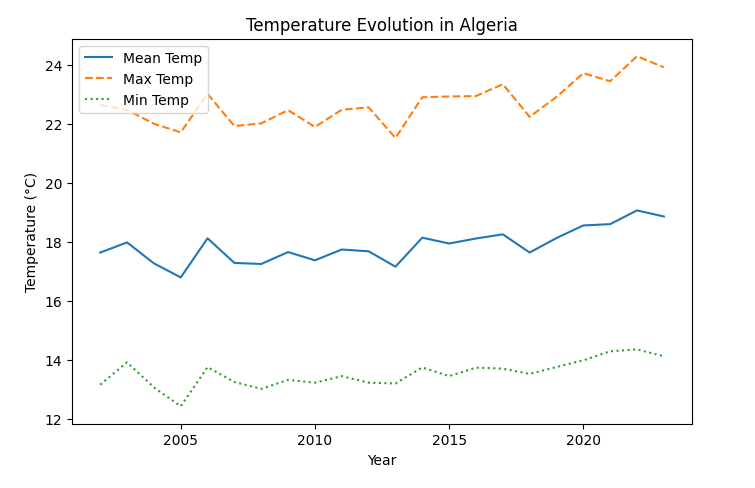

####**How does climate (temperature and ET₀) change over the years?**

separate the dataset into input data **year** and output variables **mean temperature and ET₀** in order to learn how climate indicators evolve over time and to generate future predictions up to 2040.

In [ ]:
X = yearly[["year"]] # It extracts the year column from the yearly DataFrame

y_temp = yearly["temperature_2m_mean_degC"] # It extracts the average yearly temperature column

y_et0 = yearly["et0_fao_evapotranspiration_mm"] # Extracts the yearly ET₀ values

'''
Creates a new table with years from 2023 to 2040

These years do not exist in the dataset'''

# the future years to predict .
future_years = pd.DataFrame({"year": range(2023, 2041)})



###**Forecasting with LSTM**

LSTM : Long short-term memory : neural network for time series prediction

In [ ]:
# Normalize temperature & Et0 data
# NN better works with values betweem 0 and 1

scaler_temp = MinMaxScaler()
temp_scaled = scaler_temp.fit_transform(y_temp.values.reshape(-1,1))

scaler_et0 = MinMaxScaler()
et0_scaled = scaler_et0.fit_transform(y_et0.values.reshape(-1,1))

###**sequence function** : convert time series into small sequences (ex 5 years -> predict the 6th year)

In [ ]:
# Create sequences for LSTM
# 5 : looking  at 5 past years at a time
def create_sequences(data, seq_length=5):
    # xs : input sequences ys : value to predict
    xs, ys = [], []
    for i in range(len(data)-seq_length):

        xs.append(data[i:i+seq_length]) # take 5 consecutive values
        ys.append(data[i+seq_length]) # take the next value after those 5

    return np.array(xs), np.array(ys)

creating time sequences of length 5 and then converting them into PyTorch tensors so the LSTM model can use them.

In [ ]:
seq_len = 5

# Create temperature & Et0 sequences
X_temp_seq, y_temp_seq = create_sequences(temp_scaled, seq_len)
X_et0_seq, y_et0_seq = create_sequences(et0_scaled, seq_len)

# Convert to torch tensors
# because LSTM models in PyTorch only work with tensors, not NumPy arrays.
X_temp_seq = torch.from_numpy(X_temp_seq).float()
y_temp_seq = torch.from_numpy(y_temp_seq).float()
X_et0_seq = torch.from_numpy(X_et0_seq).float()
y_et0_seq = torch.from_numpy(y_et0_seq).float()

###**LSTM Model Definition**

LSTM neural network that:

\- Looks at past values

\- Learns patterns over time

\- Predicts the next value (temperature or ET₀)

In [ ]:
# LSTM models
class LSTMModel(nn.Module):
    # input = 1 : one value per time step
    # hidden_size : size of the LSTM memory
    # output = 1 : one predicted value
    def __init__(self, input_size=1, hidden_size=16, output_size=1):
        super().__init__()

        # memory based recurrent layer : LSTM layer that remembers past information
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)

        # Converts LSTM output into a prediction
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x): # (how data flows

        out, _ = self.lstm(x) # Passes the sequence through the LSTM

        out = self.fc(out[:, -1, :]) # Takes only the last time step  to predict the next value

        return out
#  model for temperature and model for et0
temp_lstm = LSTMModel()
et0_lstm = LSTMModel()

###**LSTM Training**

In [ ]:
# Training loop (simple, small epochs for demo)
def train_lstm(model, X, y, epochs=200, lr=0.01):

    optimizer = optim.Adam(model.parameters(), lr=lr)

    criterion = nn.MSELoss() # Mean Squared Error

    for epoch in range(epochs):

        optimizer.zero_grad() # Clears old gradients before a new update

        out = model(X) # prediction

        loss = criterion(out, y) # Calculates how far predictions are from real values

        loss.backward() # Computes how to correct the model

        optimizer.step() # Updates model weights

    return model

# train model for temperature and model for et0
temp_lstm = train_lstm(temp_lstm, X_temp_seq, y_temp_seq)
et0_lstm = train_lstm(et0_lstm, X_et0_seq, y_et0_seq)


###**Predictions**

\- predicts future values step by step using the trained LSTM model.

\- Each new prediction is used to predict the next one.

     predicts future climate values by repeatedly using the LSTM model, where each new prediction becomes part of the next input.

     start from the last known values, predict the next one, then reuse that prediction as input to predict further future values.”

In [ ]:
# Forecast future values
# last_seq : last known 5 values
# step : how many future values to predict
# scaler: return values to the original scale
def forecast_lstm(model, last_seq, steps, scaler):

    preds = []
    seq = last_seq.copy() # starting with the last known data

    for _ in range(steps):
        with torch.no_grad():
            pred = model(torch.tensor(seq).float().unsqueeze(0)) # predict the next value
            # unsqueeze : LSTM excpect (batch_size, time_steps, features)
            # we have just seq -> (1, 5 seq , 1) 1 = one sequence (batch) / one value per step
            preds.append(pred.item()) # extract the number from the tensor

            # update the sequence (remove the oldest value & add the new prediction)
            seq = np.roll(seq, -1)
            seq[-1] = pred.item()
    return scaler.inverse_transform(np.array(preds).reshape(-1,1))

# Predicts 18 future years / One forecast for temperature / One forecast for ET₀
future_temp = forecast_lstm(temp_lstm, temp_scaled[-seq_len:], 18, scaler_temp)
future_et0 = forecast_lstm(et0_lstm, et0_scaled[-seq_len:], 18, scaler_et0)


In [ ]:
# Example for temperature
plt.figure(figsize=(8,5))
plt.plot(yearly["year"], y_temp, label="Observed")
plt.plot(future_years["year"], future_temp, label="Predicted", linestyle="--")

# Add +/- 1 std for confidence (toy example)
future_std = np.std(y_temp)
plt.fill_between(future_years["year"], future_temp.flatten()-future_std, future_temp.flatten()+future_std, color='blue', alpha=0.2, label="Confidence interval")

plt.xlabel("Year"); plt.ylabel("Temperature (°C)")
plt.title("Dynamic Mean Temperature Forecast until 2040")
plt.legend()
plt.show()


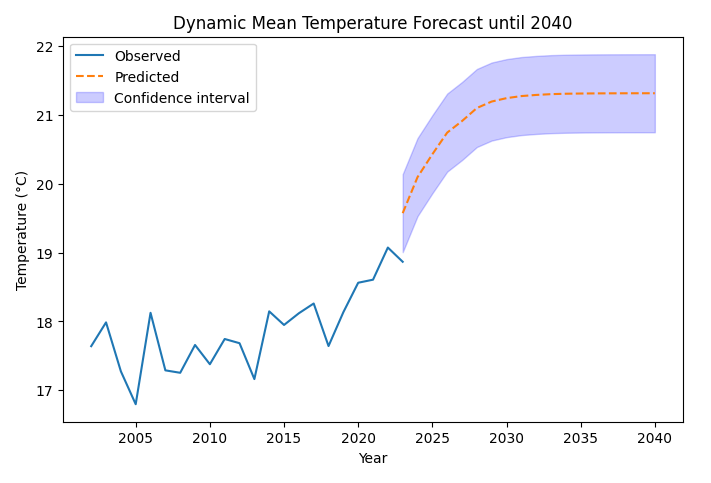

###**Prepare knowledge for RL agent**

preparing a dictionary of key climate info that the RL agent or reports can use.
It stores trends, predictions, and averages.

     how fast temperature and ET₀ are changing, what they are predicted to be in 2040, and the historical average ET₀.”

In [ ]:
knowledge = {
    # the average yearly temperature change  : temperature is rising X °C per year
    "temp_trend": float(future_temp[-1] - y_temp.values[-1]) / (future_years["year"].iloc[-1] - yearly["year"].iloc[-1]),

    # the predicted temperature for 2040
    "max_temp_2040": future_temp[-1][0],

    # the average yearly et0 change
    "et0_trend": float(future_et0[-1] - y_et0.values[-1]) / (future_years["year"].iloc[-1] - yearly["year"].iloc[-1]),

    # predicted ET₀ for 2040
    "et0_2040": future_et0[-1][0],

    # average ET₀ over all historical years : Gives a baseline to compare predictions with past data
    "avg_et0": yearly["et0_fao_evapotranspiration_mm"].mean()
}


###**Encode Queries**

**Encode Queries - Query Understanding using LLM Embeddings**

embedding converts text into numbers that represent meaning.

In [ ]:
# Pretrained language model
model_embed = SentenceTransformer('all-MiniLM-L6-v2')  # small & fast

# Converts a sentence into a numerical vector
def encode_query(query):
    # Returns embedding vector
    return torch.tensor(model_embed.encode([query]), dtype=torch.float32)


##**Reinforcement Learning Agent (DQN)**

An agent:

\- Observes a state (user question)

\- Takes an action (show trend, forecast, or report)

\- Receives a reward

###**Define DQN Network**

tiny neural network (DQN) that takes a query, processes it through two hidden layers, and outputs scores for each possible action. The agent will pick the action with the highest score or explore randomly during training.

In [ ]:
# Actions the agent can take
actions = ["show_trend", "show_forecast", "generate_report"]

# DQN parameters
input_dim = model_embed.get_sentence_embedding_dimension()  # query embedding size
hidden_dim = 16 # neurons of the hidden layer
output_dim = len(actions) # number of the actions  the agent can choose

# Random weights - they will be updated during training.
# DQN parameters with requires_grad=True
# W : Matrices that multiply inputs and pass through layers
# b : biais vectors

W1 = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.1)
b1 = nn.Parameter(torch.zeros(hidden_dim))

W2 = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.1)
b2 = nn.Parameter(torch.zeros(hidden_dim))

W3 = nn.Parameter(torch.randn(hidden_dim, output_dim) * 0.1)
b3 = nn.Parameter(torch.zeros(output_dim))


# Forward pass : computes Q-values for a query
# Higher Q-value → the agent thinks this action is better for the given query.
def dqn_forward(x):

    x = torch.relu(x @ W1 + b1) # matrix multiplication + bias (first layer) + Activation RELu for non linearity
    x = torch.relu(x @ W2 + b2) # Repeat for second layer: x @ W2 + b2
    # Output: x @ W3 + b3 → one Q-value for each possible action
    return x @ W3 + b3


###**Reward Function**

Rewards correct decisions & Penalizes wrong ones

This function teaches the agent which actions are correct for different kinds of queries.

\- High reward → correct action

\- Small reward → weak signal

\- Penalty → wrong forecast

\- Zero reward → no clue

In [ ]:
def get_reward_dqn(query, action_index):

    # index : which action the agent chose (0 = show_trend, 1 = show_forecast, 2 = generate_report)
    query = query.lower()
    action = actions[action_index]

    # Report intent (highest priority)
    if "report" in query:
        return 3 if action == "generate_report" else 0

    # 2Forecast intent (explicit + implicit)
    if (
        "forecast" in query
        or "future" in query
        or "predict" in query
        or "2040" in query
    ):

        if action == "show_forecast":
            return 3
        else:
            return -1

    #  Trend / evolution / data intent
    if (
        "trend" in query
        or "evolution" in query
        or "data" in query
    ):
        return 3 if action == "show_trend" else 0

    #  Weak signal: variable mentioned but no clear intent
    if "temperature" in query or "et0" in query:
        return 1   # small reward, NOT 2

    #  No signal
    return 0


###**Train DQN**

**1. parameters**

In [ ]:
optimizer = optim.Adam([W1, b1, W2, b2, W3, b3], lr=0.01)
criterion = nn.MSELoss()

# Training queries
queries_train = [
    "Show temperature evolution",
    "Show temperature forecast",
    "Show ET0 forecast",
    "Show temperature and ET0 forecast",
    "Generate climate report",
    "Show climate data for Algeria",
    "ET0 trend",
    "Temperature trend",
    "Predict ET0 in the future",
    "Predict temperature in the future"
]

n_epochs = 500
# more exploration : how often the agent tries a random action instead of the best predicted action
epsilon = 0.3

# To store average loss per epoch
epoch_losses = []

**2. loop**

In [ ]:
for epoch in range(n_epochs):
    epsilon = max(0.1, 0.3 * (1 - epoch / n_epochs)) # Gradually reduce exploration as training progresses.
    np.random.shuffle(queries_train) # randomize the order of queries each epoch.
    batch_loss = 0.0

    for q in queries_train:

        state = encode_query(q).detach()  # query -> vector
        q_values = dqn_forward(state) # network predicts Q-values for all actions.

        # Exploration vs exploitation
        if np.random.rand() < epsilon:
            action_index = np.random.randint(len(actions)) # exploration
        else: # choose the highest Q-value action (exploitation)
            action_index = torch.argmax(q_values).item()

        # Get reward for chosen action (reward here is like te real value of the action)
        reward = get_reward_dqn(q, action_index)
        if reward is None:
            reward = 0
        reward = float(reward)


        # in target : replace the Q-value of the chosen action with the actual reward.
        target = q_values.clone().detach()
        target[0, action_index] = reward

        # Backpropagation: update weights
        optimizer.zero_grad()
        loss = criterion(q_values, target)
        loss.backward()
        optimizer.step()

        batch_loss += loss.item()


    # Average loss for this epoch
    avg_loss = batch_loss / len(queries_train)
    epoch_losses.append(avg_loss)

    # Optional: print every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Avg Loss: {avg_loss:.4f}")


In [ ]:
# After training: visualize loss curve
plt.figure(figsize=(8,5))
plt.plot(range(1, n_epochs+1), epoch_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("DQN Training Loss Over Epochs")
plt.legend()
plt.show()

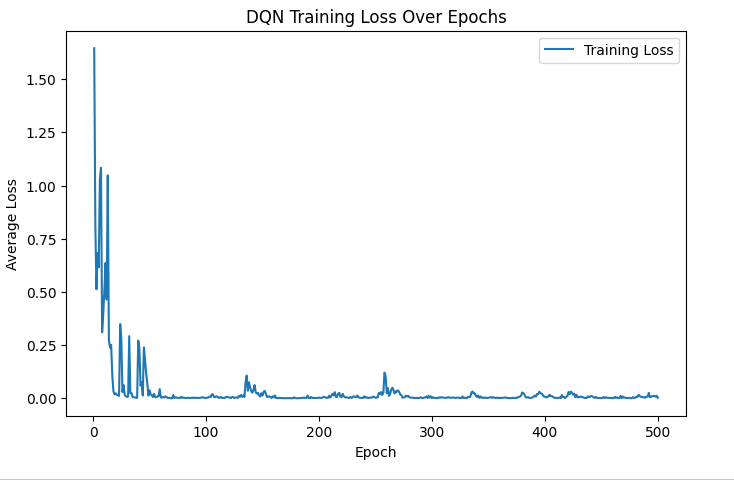

##**Agent Execution Layer**

###**Agent decision function**

\- This function takes a **text query**, encodes it, and passes it through the **trained DQN** to get a Q-value for each possible action.

\- then converts these Q-values into probabilities using softmax,

\- introducing **stochasticity** so higher Q-values are more likely but not guaranteed.

\- randomly samples an action based on these probabilities and returns it.

In [ ]:
def agent_decision_dqn(query, temperature=1.0):

    state = encode_query(query).detach()  #
    q_values = dqn_forward(state)

    # Make sure q_values is 1D
    q_values = q_values.flatten()

    # convert q-values to probabilities
    probs = torch.softmax(q_values / temperature, dim=0).detach().numpy()

    # Use probs for sampling
    action_index = np.random.choice(len(actions), p=probs)

    return actions[action_index]


###**Connect RL agent to real outputs**

this function  integrates the agent’s decision with the climate data and visualizations to respond to the query.

\- calls the **agent_decision_dqn()** to let the trained DQN agent choose an action

\- depending on the choosen action :    
    
     - generate_report → creates a summary table with trends, 2040 predictions, and average values, optionally saving it to a PDF.

     - show_trend → displays historical data tables and interactive plots for temperature and ET₀, optionally filtered for a specific year.

     - show_forecast → displays future predictions in a table and interactive plots, highlighting the requested year if present.


In [ ]:
def execute_agent_table_pdf(query, pdf=None):

    action = agent_decision_dqn(query) # Agent chooses what to do

    # Display formal heading in notebook
    display(Markdown(f"## User query: `{query}`"))
    display(Markdown(f"**Agent action:** `{action}`"))

    # Detect a specific year in the query
    match = re.search(r"\b(20\d{2})\b", query)
    year_requested = int(match.group(1)) if match else None


# -------------------------------------------- report ---------------------------------------------------


    if action == "generate_report":
        # Table for climate report
        data_table = {
            "Category": ["Temperature trend (°C/year)", "Expected mean temp 2040 (°C)",
                         "ET₀ trend (mm/year)", "Expected ET₀ 2040 (mm)", "Historical average ET₀ (mm)"],
            "Value": [f"{knowledge['temp_trend']:.3f}",
                      f"{knowledge['max_temp_2040']:.2f}",
                      f"{knowledge['et0_trend']:.3f}",
                      f"{knowledge['et0_2040']:.2f}",
                      f"{knowledge['avg_et0']:.2f}"]
        }
        df = pd.DataFrame(data_table)
        display(df)
        display(Markdown("**Conclusion:** Persistent warming trend with increasing evapotranspiration."))

        if pdf:
            text = "\n".join([f"{cat}: {val}" for cat, val in zip(data_table["Category"], data_table["Value"])])
            text += "\nConclusion: Persistent warming trend with increasing evapotranspiration."
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8,5))
            plt.text(0.01,0.99, text, va="top", ha="left", fontsize=10, wrap=True)
            plt.axis("off")
            pdf.savefig()
            plt.close()


# ------------------------------------------------ show trend -----------------------------------------------



    elif action == "show_trend":
        trend_df = yearly[["year","temperature_2m_mean_degC","temperature_2m_max_degC",
                           "temperature_2m_min_degC","et0_fao_evapotranspiration_mm"]].copy()
        trend_df.rename(columns={
            "temperature_2m_mean_degC":"Mean Temp (°C)",
            "temperature_2m_max_degC":"Max Temp (°C)",
            "temperature_2m_min_degC":"Min Temp (°C)",
            "et0_fao_evapotranspiration_mm":"ET₀ (mm)"
        }, inplace=True)

        # Display table (filtered if year requested)
        if year_requested and year_requested in trend_df["year"].values:
            display(Markdown(f"**Filtered trend for year {year_requested}:**"))
            display(trend_df[trend_df["year"] == year_requested])
        else:
            display(trend_df)

        # Interactive Plotly temperature plot
        fig_temp = go.Figure()
        fig_temp.add_trace(go.Scatter(x=trend_df["year"], y=trend_df["Mean Temp (°C)"],
                                      mode='lines+markers', name="Mean Temp"))
        fig_temp.add_trace(go.Scatter(x=trend_df["year"], y=trend_df["Max Temp (°C)"],
                                      mode='lines+markers', name="Max Temp", line=dict(dash='dash')))
        fig_temp.add_trace(go.Scatter(x=trend_df["year"], y=trend_df["Min Temp (°C)"],
                                      mode='lines+markers', name="Min Temp", line=dict(dash='dot')))

        if year_requested and year_requested in trend_df["year"].values:
            idx = trend_df[trend_df["year"] == year_requested].index[0]
            fig_temp.add_trace(go.Scatter(
                x=[year_requested],
                y=[trend_df.loc[idx, "Mean Temp (°C)"]],
                mode='markers',
                marker=dict(color='red', size=12),
                name=f"{year_requested} Mean Temp"
            ))

        fig_temp.update_layout(title="Temperature Evolution",
                               xaxis_title="Year", yaxis_title="Temperature (°C)")
        fig_temp.show()

        # Interactive ET₀ plot
        fig_et0 = go.Figure()
        fig_et0.add_trace(go.Scatter(x=trend_df["year"], y=trend_df["ET₀ (mm)"],
                                     mode='lines+markers', name="ET₀", line=dict(color='orange')))
        if year_requested and year_requested in trend_df["year"].values:
            idx = trend_df[trend_df["year"] == year_requested].index[0]
            fig_et0.add_trace(go.Scatter(
                x=[year_requested],
                y=[trend_df.loc[idx, "ET₀ (mm)"]],
                mode='markers',
                marker=dict(color='red', size=12),
                name=f"{year_requested} ET₀"
            ))

        fig_et0.update_layout(title="ET₀ Trend", xaxis_title="Year", yaxis_title="ET₀ (mm)")
        fig_et0.show()


# ------------------------------------------------ show forecast -----------------------------------------------


    elif action == "show_forecast":
        forecast_table = pd.DataFrame({
            "Variable":["Mean Temperature (°C)", "ET₀ (mm)"],
            "2040 Prediction":[f"{knowledge['max_temp_2040']:.2f}", f"{knowledge['et0_2040']:.2f}"]
        })
        display(Markdown("**Forecast up to 2040:**"))
        display(forecast_table)

        forecast_years_list = [year_requested] if year_requested else future_years["year"].tolist()

        for var_name, obs_col, pred_values, color_obs in [("Temperature", "temperature_2m_mean_degC", future_temp, "blue"),
                                                         ("ET₀", "et0_fao_evapotranspiration_mm", future_et0, "orange")]:
            fig = go.Figure()
            # Observed
            fig.add_trace(go.Scatter(
                x=yearly["year"],
                y=yearly[obs_col],
                mode='lines+markers',
                name=f'Observed {var_name}',
                line=dict(color=color_obs)
            ))
            # Predicted
            fig.add_trace(go.Scatter(
                x=future_years["year"],
                y=pred_values.flatten(),
                mode='lines+markers',
                name=f'Predicted {var_name}',
                line=dict(color='green', dash='dash')
            ))
            # Highlight requested years
            for y in forecast_years_list:
                if y in future_years["year"].values:
                    idx = future_years[future_years["year"] == y].index[0]
                    fig.add_trace(go.Scatter(
                        x=[y],
                        y=[pred_values[idx]],
                        mode='markers',
                        marker=dict(color='red', size=12),
                        name=f'{y} Forecast'
                    ))

            fig.update_layout(title=f"{var_name} Forecast",
                              xaxis_title="Year",
                              yaxis_title=var_name,
                              template="plotly_white")
            fig.show()


##**FINAL TEST (Agent execution)**

In [ ]:
# Optional: save PDF if needed
save_pdf = input("Do you want to save a PDF report? (y/n): ").lower() == "y"
pdf = PdfPages("Climate_Report_Algeria_Interactive.pdf") if save_pdf else None

print("🌡️ Climate Agent ready! Type 'exit' or 'quit' to stop.")

while True:
    query = input("Ask climate agent: ")
    if query.lower() in ["exit", "quit"]:
        break
    execute_agent_table_pdf(query, pdf=pdf)
if save_pdf:
    pdf.close()
    print("✅ PDF saved as Climate_Report_Algeria_Interactive.pdf")


**Test 1**

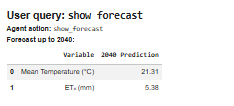


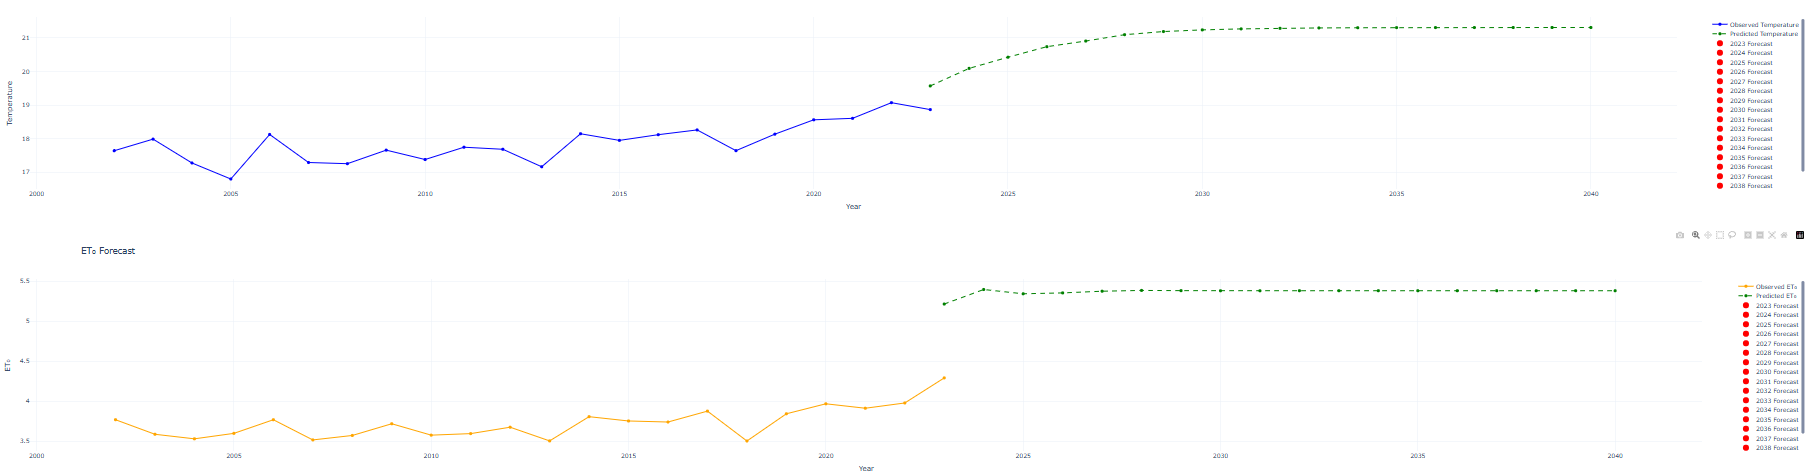

**Test 2**

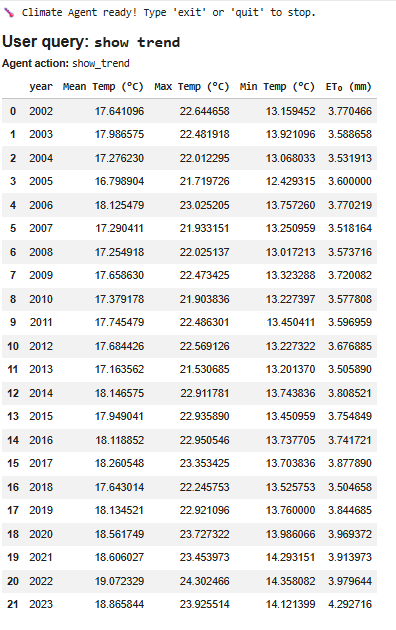

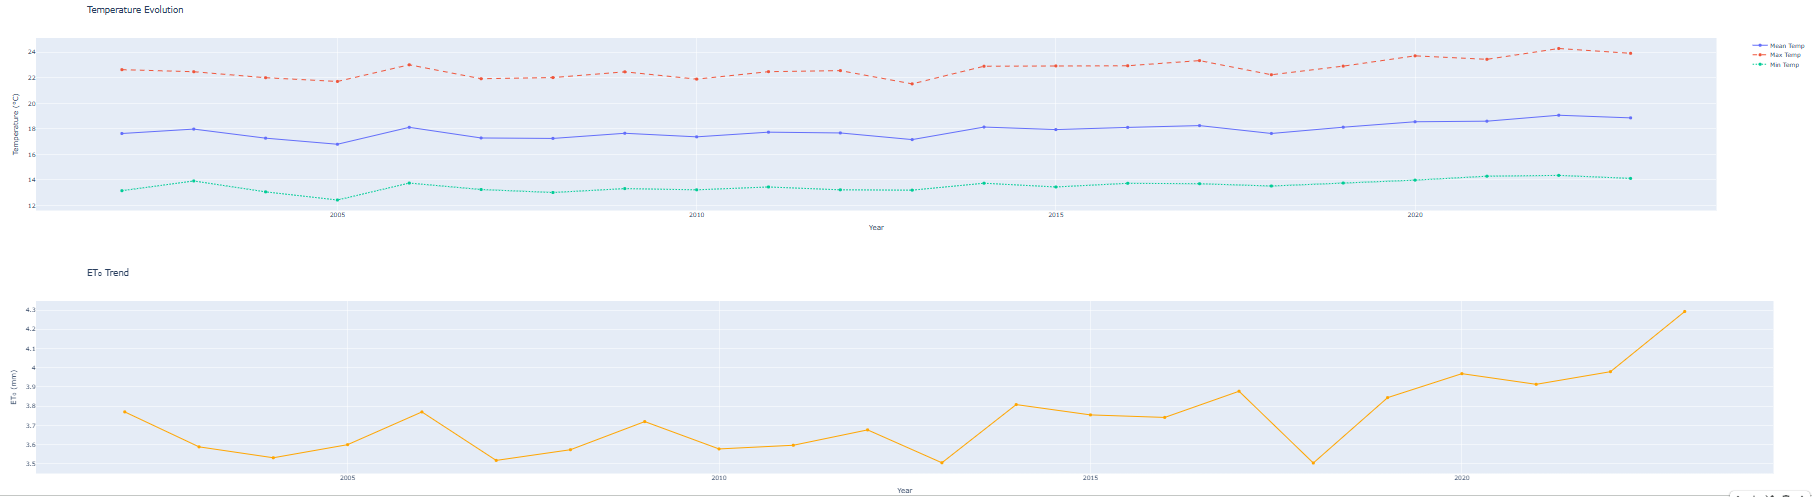


**Test 3**

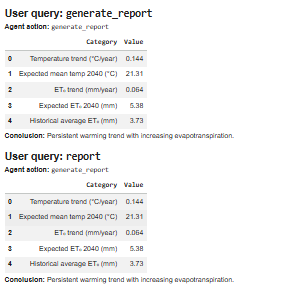

##**Gradio Web Interface**

In [ ]:
def chat_agent_gradio_html(query):
    # Decide action
    action = agent_decision_dqn(query)

    html_output = f"<b>User query:</b> {query}<br><b>Agent action:</b> {action}<br><br>"

    if action == "show_trend":
        trend_df = yearly[["year","temperature_2m_mean_degC","temperature_2m_max_degC",
                           "temperature_2m_min_degC","et0_fao_evapotranspiration_mm"]].copy()
        trend_df.rename(columns={
            "temperature_2m_mean_degC":"Mean Temp (°C)",
            "temperature_2m_max_degC":"Max Temp (°C)",
            "temperature_2m_min_degC":"Min Temp (°C)",
            "et0_fao_evapotranspiration_mm":"ET₀ (mm)"
        }, inplace=True)

        html_output += "<b>Trend Table:</b><br>" + trend_df.to_html(index=False)

        # Plotly figure
        fig_temp = go.Figure()
        fig_temp.add_trace(go.Scatter(x=trend_df["year"], y=trend_df["Mean Temp (°C)"],
                                      mode='lines+markers', name="Mean Temp"))
        fig_temp.add_trace(go.Scatter(x=trend_df["year"], y=trend_df["Max Temp (°C)"],
                                      mode='lines+markers', name="Max Temp", line=dict(dash='dash')))
        fig_temp.add_trace(go.Scatter(x=trend_df["year"], y=trend_df["Min Temp (°C)"],
                                      mode='lines+markers', name="Min Temp", line=dict(dash='dot')))
        return html_output, fig_temp

    elif action == "show_forecast":
        forecast_table = pd.DataFrame({
            "Variable":["Mean Temperature (°C)", "ET₀ (mm)"],
            "2040 Prediction":[f"{knowledge['max_temp_2040']:.2f}", f"{knowledge['et0_2040']:.2f}"]
        })
        html_output += "<b>Forecast up to 2040:</b><br>" + forecast_table.to_html(index=False)

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=future_years["year"], y=future_temp.flatten(),
                                 mode='lines+markers', name="Predicted Temp"))
        return html_output, fig

    elif action == "generate_report":
        html_output += f"""
<b>Climate Report:</b><br>
Temperature trend: {knowledge['temp_trend']:.3f} °C/year<br>
Expected mean temp 2040: {knowledge['max_temp_2040']:.2f} °C<br>
ET₀ trend: {knowledge['et0_trend']:.3f} mm/year<br>
Expected ET₀ 2040: {knowledge['et0_2040']:.2f} mm<br>
Historical average ET₀: {knowledge['avg_et0']:.2f} mm
"""
        return html_output, None


In [ ]:
iface = gr.Interface(
    fn=chat_agent_gradio_html,
    inputs=gr.Textbox(lines=2, placeholder="Ask climate agent..."),
    outputs=[
        gr.HTML(label="Agent output"),  # Use HTML to display tables properly
        gr.Plot(label="Graph")          # Plotly graph
    ],
    title="Algeria Climate Agent",
    description="Ask questions about temperature, ET₀, forecasts, and reports."
)

iface.launch()
